FileNotFoundError: Missing file: allen_cahn_python.mat

Burgers reference data: using ../data/burgers.mat
Reference loaded:
  x: (512,) range: -1.0 to 1.0
  t: (201,) range: 0.0 to 1.0
  u_ref: (201, 512)
  u_ref min/max: -0.999995275372036 0.999995275372036
  nu: 0.003183098861837907
Sto-SQP: using ../1/theta_star_pointwise_jitter_1e-5.npz.npy
Sto-SQP: loaded ../1/theta_star_pointwise_jitter_1e-5.npz.npy, theta size=1981
ALM: using ../theta_traditional_alm_burgers_lbfgs_20000_best.npy
ALM: loaded ../theta_traditional_alm_burgers_lbfgs_20000_best.npy, theta size=1981
Adam: using ../burgers_adam_theta.npy
Adam: loaded ../burgers_adam_theta.npy, theta size=7851

Parameter counts:
  Sto-SQP theta size = 1981
  ALM theta size     = 1981
  Adam theta size    = 7851

Full-grid metrics:
Sto-SQP              MSE = 1.441166e-07   relL2 = 6.188130e-04
ALM                  MSE = 4.005298e-06   relL2 = 3.262270e-03
Adam                 MSE = 1.766317e-04   relL2 = 2.166391e-02

Error color scale:
  vmin = 1e-08
  vmax = 0.2166967150868283

Saved figure

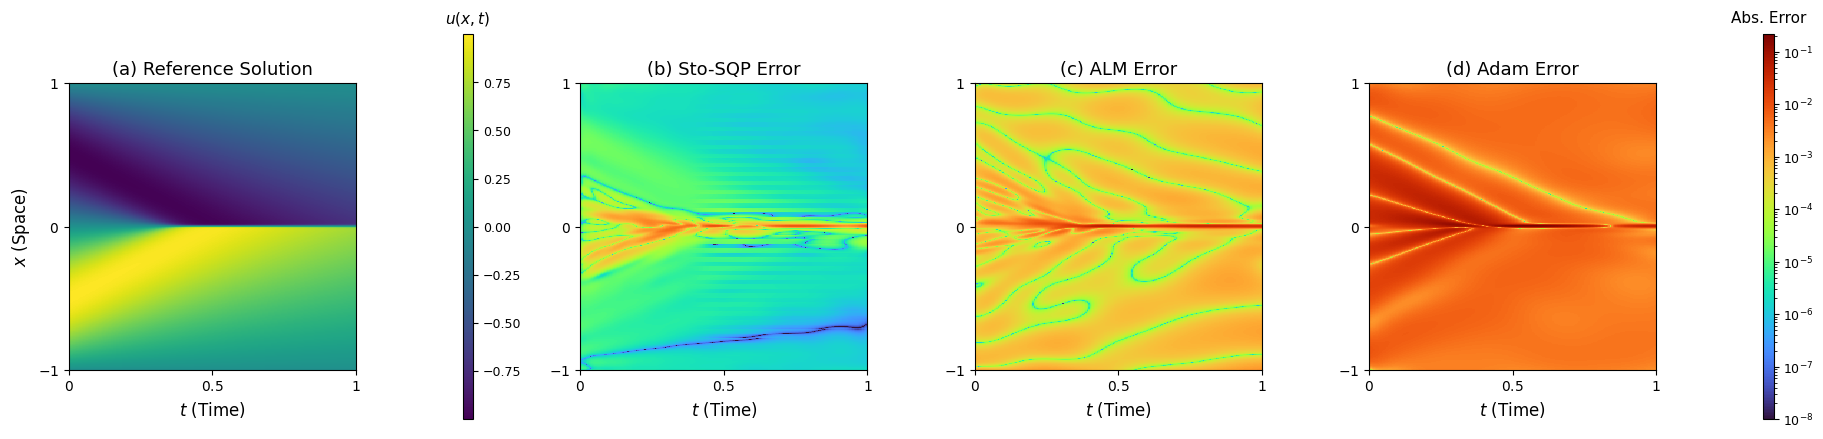

In [2]:
# ============================================================
# Burgers heatmaps: Reference + Sto-SQP error + ALM error + Adam error
# NO deterministic SQP heatmap
# ============================================================

import os
from pathlib import Path

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# USER SETTINGS
# ============================================================

# Run this from:
#   main/heatmaps/

# ------------------------------------------------------------
# Reference Burgers data
# ------------------------------------------------------------
REF_CANDIDATES = [
    "data/burgers.mat",
    "../1/data/burgers.mat",
    "../data/burgers.mat",
    "../1/burgers.mat",
    "../burgers.mat",
]

# ------------------------------------------------------------
# Model files
# ------------------------------------------------------------

# Sto-SQP is in folder 1.
STO_SQP_CANDIDATES = [
    "../1/theta_star_pointwise_jitter_1e-5.npz.npy",
    "../1/theta_star_pointwise_jitter_1e-5.npy",
    "../1/theta_star_pointwise_jitter_1e-5.npz",
]

# ALM candidates
ALM_CANDIDATES = [
    "../1/theta_traditional_alm_burgers_lbfgs_20000_best.npy",
    "../1/theta_traditional_alm_burgers_lbfgs_20000_final.npy",
    "../1/traditional_alm_burgers_best.npy",
    "../1/traditional_alm_burgers_final.npy",
    "../theta_traditional_alm_burgers_lbfgs_20000_best.npy",
]

# Adam candidates
ADAM_CANDIDATES = [
    "../1/burgers_adam_theta.npy",
    "../burgers_adam_theta.npy",
]

SAVE_PREFIX = "burgers_reference_plus_sto_alm_adam_errors"

# ------------------------------------------------------------
# Architecture
# ------------------------------------------------------------
# SQP / ALM Burgers: [2] + [30]*3 + [1]
SQP_LAYER_SIZES = [2, 30, 30, 30, 1]
ALM_LAYER_SIZES = [2, 30, 30, 30, 1]

# Adam Burgers: hidden_dim=50, num_hidden=4
ADAM_LAYER_SIZES = [2, 50, 50, 50, 50, 1]

SQP_ACTIVATION = "tanh"
ALM_ACTIVATION = "tanh"
ADAM_ACTIVATION = "tanh"

# Keep this consistent with your saved models.
# Your uploaded Burgers plotting code had this as False.
NORMALIZE_INPUT = False

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
REF_CMAP = "viridis"
ERR_CMAP = "turbo"

ERR_FLOOR = 1e-8
FIG_DPI = 300


# ============================================================
# FILE HELPERS
# ============================================================

def find_existing_file(candidates, name):
    for p in candidates:
        if Path(p).exists():
            print(f"{name}: using {p}")
            return p

    raise FileNotFoundError(
        f"Could not find {name}. Tried:\n" + "\n".join(candidates)
    )


def load_theta(candidates, name):
    path = find_existing_file(candidates, name)
    obj = np.load(path, allow_pickle=True)

    # If npz, try common keys.
    if hasattr(obj, "files"):
        keys = obj.files
        for key in ["theta", "theta_star", "params_flat"]:
            if key in keys:
                theta = np.asarray(obj[key], dtype=np.float64).reshape(-1)
                print(f"{name}: loaded {path}, key={key}, theta size={theta.size}")
                return path, theta
        raise KeyError(f"{path} is npz with keys {keys}, but no theta key found.")

    theta = np.asarray(obj, dtype=np.float64).reshape(-1)
    print(f"{name}: loaded {path}, theta size={theta.size}")
    return path, theta


# ============================================================
# REFERENCE DATA
# ============================================================

def load_burgers_reference():
    path = find_existing_file(REF_CANDIDATES, "Burgers reference data")
    data = scipy.io.loadmat(path)

    t = np.asarray(data["t"]).squeeze().astype(np.float64)
    x = np.asarray(data["x"]).squeeze().astype(np.float64)
    u_ref = np.asarray(data["usol"], dtype=np.float64)

    if u_ref.shape == (len(x), len(t)):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference shape mismatch: usol.shape={u_ref.shape}, "
            f"expected {(len(t), len(x))}"
        )

    nu = None
    if "nu" in data:
        nu = float(np.asarray(data["nu"]).squeeze())

    print("Reference loaded:")
    print("  x:", x.shape, "range:", float(x[0]), "to", float(x[-1]))
    print("  t:", t.shape, "range:", float(t[0]), "to", float(t[-1]))
    print("  u_ref:", u_ref.shape)
    print("  u_ref min/max:", float(np.min(u_ref)), float(np.max(u_ref)))
    if nu is not None:
        print("  nu:", nu)

    return x, t, u_ref


# ============================================================
# MLP HELPERS
# ============================================================

def normalize_xt(X, x_min, x_max, t_min, t_max):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * (x - x_min) / (x_max - x_min + 1e-30) - 1.0
    t_n = 2.0 * (t - t_min) / (t_max - t_min + 1e-30) - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "relu":
        return np.maximum(z, 0.0)
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation, normalize_input,
                x_min, x_max, t_min, t_max):
    params = unflatten_theta(theta, layer_sizes)

    H = np.asarray(X, dtype=np.float64)

    if normalize_input:
        H = normalize_xt(H, x_min, x_max, t_min, t_max)

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t,
                    activation="tanh", normalize_input=True):
    """
    Returns u_pred with shape (nt, nx).
    Input order: [x,t].
    """
    TT, XX = np.meshgrid(t, x, indexing="ij")

    X_eval = np.stack(
        [XX.reshape(-1), TT.reshape(-1)],
        axis=1,
    )

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
        x_min=float(x[0]),
        x_max=float(x[-1]),
        t_min=float(t[0]),
        t_max=float(t[-1]),
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2) / (np.mean(b ** 2) + 1e-30)))


# ============================================================
# MAIN
# ============================================================

def main():
    # --------------------------------------------------------
    # Load reference and models
    # --------------------------------------------------------
    x, t, u_ref = load_burgers_reference()

    sto_path, theta_sto = load_theta(STO_SQP_CANDIDATES, "Sto-SQP")
    alm_path, theta_alm = load_theta(ALM_CANDIDATES, "ALM")
    adam_path, theta_adam = load_theta(ADAM_CANDIDATES, "Adam")

    print("\nParameter counts:")
    print("  Sto-SQP theta size =", theta_sto.size)
    print("  ALM theta size     =", theta_alm.size)
    print("  Adam theta size    =", theta_adam.size)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    u_sto = predict_on_grid(
        theta_sto,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_alm = predict_on_grid(
        theta_alm,
        ALM_LAYER_SIZES,
        x,
        t,
        activation=ALM_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_adam = predict_on_grid(
        theta_adam,
        ADAM_LAYER_SIZES,
        x,
        t,
        activation=ADAM_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    # --------------------------------------------------------
    # Errors
    # --------------------------------------------------------
    err_sto = np.abs(u_sto - u_ref)
    err_alm = np.abs(u_alm - u_ref)
    err_adam = np.abs(u_adam - u_ref)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    print("\nFull-grid metrics:")
    for name, upred in [
        ("Sto-SQP", u_sto),
        ("ALM", u_alm),
        ("Adam", u_adam),
    ]:
        print(
            f"{name:<20s} MSE = {mse(upred, u_ref):.6e}   "
            f"relL2 = {rel_l2(upred, u_ref):.6e}"
        )

    # --------------------------------------------------------
    # Color scales
    # --------------------------------------------------------
    ref_vabs = float(np.max(np.abs(u_ref)))
    ref_vmin = -ref_vabs
    ref_vmax = ref_vabs

    all_err = np.concatenate([
        err_sto.ravel(),
        err_alm.ravel(),
        err_adam.ravel(),
    ])

    err_vmax = max(float(np.max(all_err)), ERR_FLOOR * 10.0)

    print("\nError color scale:")
    print("  vmin =", ERR_FLOOR)
    print("  vmax =", err_vmax)

    err_norm = LogNorm(vmin=ERR_FLOOR, vmax=err_vmax)

    err_sto_plot = np.maximum(err_sto, ERR_FLOOR)
    err_alm_plot = np.maximum(err_alm, ERR_FLOOR)
    err_adam_plot = np.maximum(err_adam, ERR_FLOOR)

    extent = [float(t[0]), float(t[-1]), float(x[0]), float(x[-1])]

    # --------------------------------------------------------
    # Figure layout: Reference + Sto-SQP error + ALM error + Adam error
    # --------------------------------------------------------
    fig = plt.figure(figsize=(22, 5.0))

    gs = fig.add_gridspec(
        1,
        6,
        width_ratios=[1.0, 0.035, 1.0, 1.0, 1.0, 0.035],
        wspace=0.55,
    )

    ax_ref = fig.add_subplot(gs[0, 0])
    cax_ref = fig.add_subplot(gs[0, 1])

    ax_sto = fig.add_subplot(gs[0, 2])
    ax_alm = fig.add_subplot(gs[0, 3])
    ax_adam = fig.add_subplot(gs[0, 4])

    cax_err = fig.add_subplot(gs[0, 5])

    # Reference
    im_ref = ax_ref.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=ref_vmin,
        vmax=ref_vmax,
        interpolation="nearest",
    )

    cb_ref = fig.colorbar(im_ref, cax=cax_ref)
    cb_ref.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb_ref.ax.tick_params(labelsize=9)

    ax_ref.set_title("(a) Reference Solution", fontsize=13)

    # Sto-SQP error
    im_sto = ax_sto.imshow(
        err_sto_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ERR_CMAP,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_sto.set_title("(b) Sto-SQP Error", fontsize=13)

    # ALM error
    im_alm = ax_alm.imshow(
        err_alm_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ERR_CMAP,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_alm.set_title("(c) ALM Error", fontsize=13)

    # Adam error
    im_adam = ax_adam.imshow(
        err_adam_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ERR_CMAP,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_adam.set_title("(d) Adam Error", fontsize=13)

    cb_err = fig.colorbar(im_adam, cax=cax_err)
    cb_err.ax.set_title("Abs. Error", fontsize=11, pad=8)
    cb_err.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------
    all_axes = [ax_ref, ax_sto, ax_alm, ax_adam]

    for ax in all_axes:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)

        ax.set_xlim(float(t[0]), float(t[-1]))
        ax.set_ylim(float(x[0]), float(x[-1]))

        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_xticklabels([r"$0$", r"$0.5$", r"$1$"])

        ax.set_yticks([-1.0, 0.0, 1.0])
        ax.set_yticklabels([r"$-1$", r"$0$", r"$1$"])

        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    ax_ref.set_ylabel(r"$x$ (Space)", fontsize=12)

    for ax in [ax_sto, ax_alm, ax_adam]:
        ax.set_ylabel("")

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(f"{SAVE_PREFIX}.png", dpi=FIG_DPI, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight", pad_inches=0.02)

    print(f"\nSaved figure -> {SAVE_PREFIX}.png")
    print(f"Saved figure -> {SAVE_PREFIX}.pdf")

    plt.show()


if __name__ == "__main__":
    main()